# Practical 3: The Optimizer Showdown & Hyperparameter Tuning
## Deep Learning Lab | BTech Semester 4

### Objective
Analyze the impact of different optimization algorithms on convergence speed.
train test accuracy increased by playing with epoches and doing some changes


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
print(f'TensorFlow: {tf.__version__}')

TensorFlow: 2.20.0


## Step 2: Load Fashion MNIST
Fashion MNIST has 70,000 grayscale images (28x28 pixels) of 10 clothing categories — a harder alternative to handwritten digits.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training: (60000, 28, 28), Test: (10000, 28, 28)


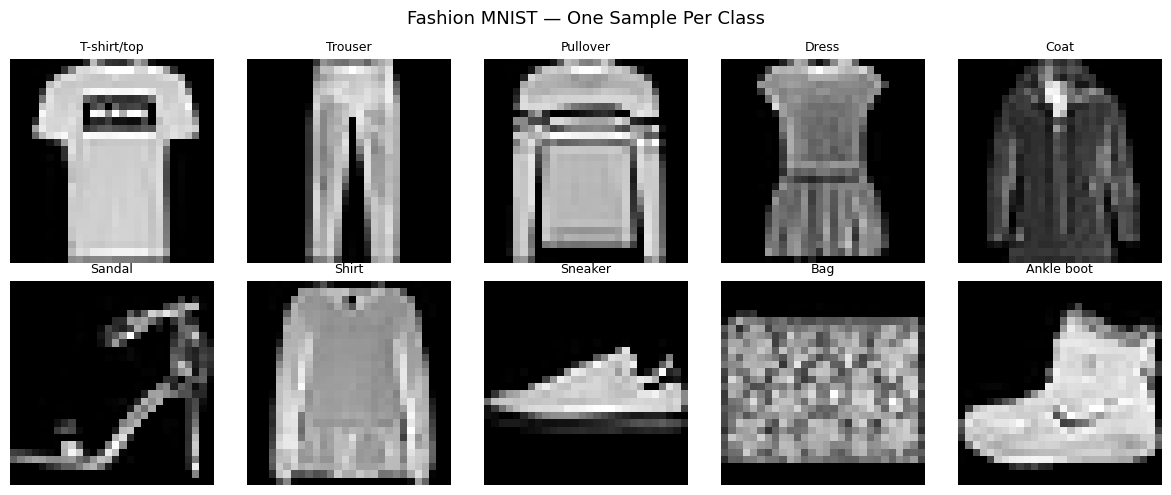

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

print(f'Training: {X_train.shape}, Test: {X_test.shape}')

# Visualize one image per class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    idx = np.where(y_train == i)[0][0]
    ax.imshow(X_train[idx], cmap='gray')
    ax.set_title(class_names[i], fontsize=9)
    ax.axis('off')
plt.suptitle('Fashion MNIST — One Sample Per Class', fontsize=13)
plt.tight_layout()
plt.show()

## Step 3: Preprocess Data
- Normalize pixels from [0,255] to [0,1] — smaller values help gradient descent converge faster
- Flatten 28x28 images into 784-length vectors for Dense layers

In [3]:
# Reshape (no normalization here)
X_train_flat = X_train.reshape(-1, 784)
X_test_flat  = X_test.reshape(-1, 784)

# Subset for faster training on CPU (increase if you have GPU)
SUBSET = 15000
X_sub = X_train_flat[:SUBSET]
y_sub = y_train[:SUBSET]

# Compute mean & std from training subset
mean = X_sub.mean()
std = X_sub.std()

# Apply standardization
X_sub = (X_sub - mean) / std
X_test_flat = (X_test_flat - mean) / std

print(f'Subset shape: {X_sub.shape}, value range: [{X_sub.min():.2f}, {X_sub.max():.2f}]')

Subset shape: (15000, 784), value range: [-0.81, 2.01]


## Step 4: Optimizer Theory

**SGD:** W = W - lr * gradient  — simple but slow

**SGD + Momentum:** velocity = beta*v + lr*gradient; W = W - velocity — adds inertia

**Nesterov:** computes gradient at future predicted position (look-ahead) — smarter momentum

**Adam:** adapts learning rate per parameter using estimates of first and second moments of gradients

In [4]:
def build_network():
    """Identical shallow network used for all optimizer comparisons.
    Same architecture ensures convergence differences come only from the optimizer."""
    model = keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(784,), name='hidden1'),
        layers.Dense(64,  activation='relu', name='hidden2'),
        layers.Dense(10,  activation='softmax', name='output')  # 10 classes
    ])
    return model

# Three optimizer configurations to compare
optimizer_configs = [
    {'name': '1. SGD (lr=0.01)',
     'optimizer': optimizers.SGD(learning_rate=0.01),
     'color': 'red', 'linestyle': '-'},
    {'name': '2. SGD + Momentum + Nesterov',
     'optimizer': optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
     'color': 'blue', 'linestyle': '--'},
    {'name': '3. Adam (lr=0.001)',
     'optimizer': optimizers.Adam(learning_rate=0.001),
     'color': 'green', 'linestyle': '-.'},
]

print('Optimizer configurations:')
for c in optimizer_configs:
    print(f'  {c["name"]}')

Optimizer configurations:
  1. SGD (lr=0.01)
  2. SGD + Momentum + Nesterov
  3. Adam (lr=0.001)


## Step 5: Train All Three Configurations
Each model starts with the SAME random weights (same seed) for a fair comparison.

In [5]:
EPOCHS = 50
BATCH_SIZE = 64
results = {}

for cfg in optimizer_configs:
    print(f'\nTraining: {cfg["name"]}')
    tf.random.set_seed(42)  # Same initialization for fair comparison
    model = build_network()
    model.compile(
        optimizer=cfg['optimizer'],
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(X_sub, y_sub, epochs=EPOCHS, batch_size=BATCH_SIZE,
                        validation_split=0.15, verbose=0)
    results[cfg['name']] = {'history': history, 'color': cfg['color'],
                             'linestyle': cfg['linestyle'], 'model': model}
    print(f'  Final Val Acc: {history.history["val_accuracy"][-1]*100:.2f}%')

print('\nAll configurations trained!')


Training: 1. SGD (lr=0.01)
  Final Val Acc: 85.20%

Training: 2. SGD + Momentum + Nesterov
  Final Val Acc: 85.60%

Training: 3. Adam (lr=0.001)
  Final Val Acc: 85.78%

All configurations trained!


## Step 6: Compare Convergence — Loss vs. Epochs (Main Plot)

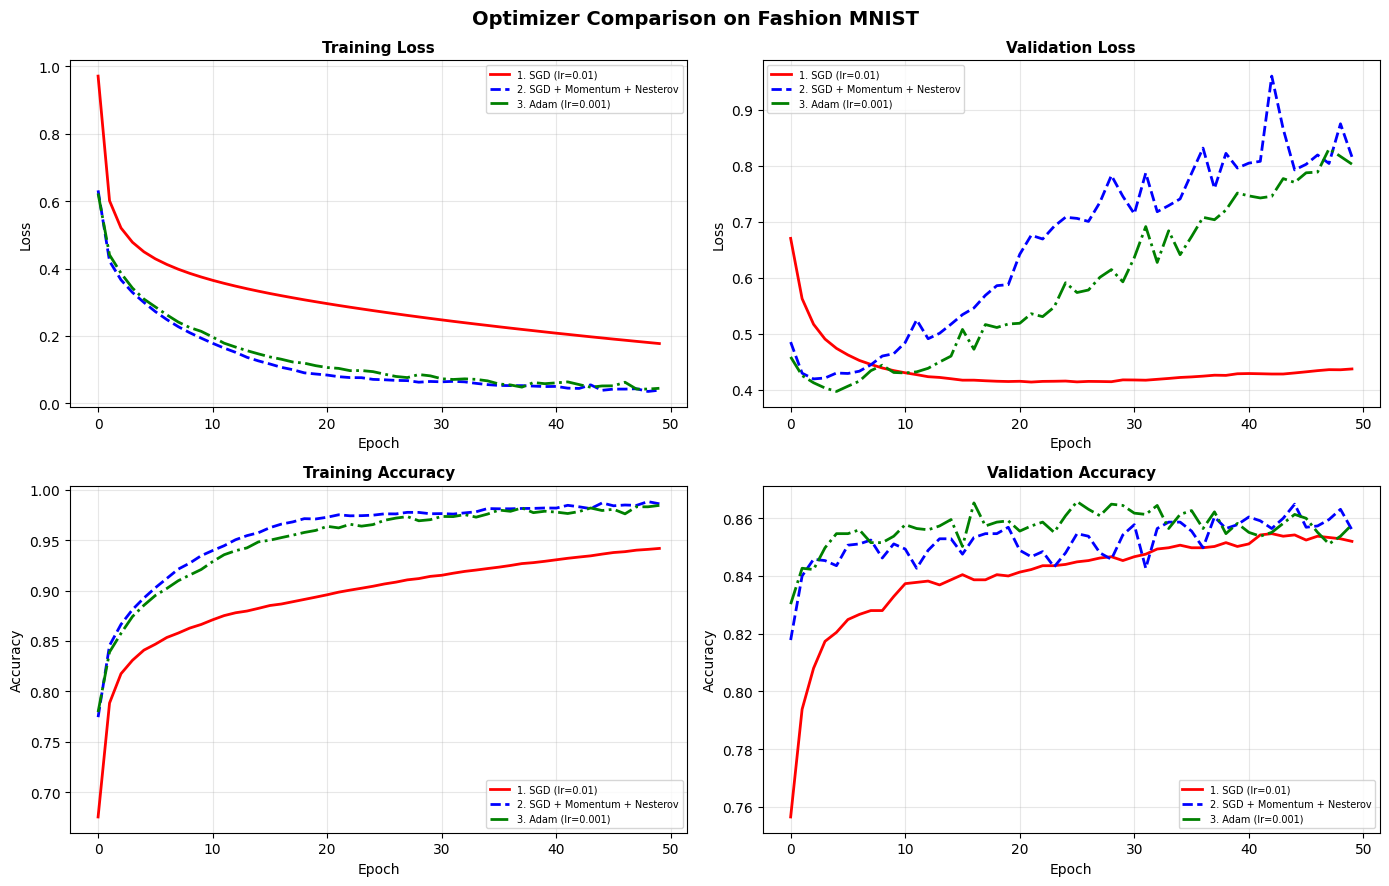

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

plot_configs = [
    ('loss',         'Training Loss',      axes[0,0]),
    ('val_loss',     'Validation Loss',    axes[0,1]),
    ('accuracy',     'Training Accuracy',  axes[1,0]),
    ('val_accuracy', 'Validation Accuracy',axes[1,1]),
]

for metric, title, ax in plot_configs:
    for name, res in results.items():
        ax.plot(res['history'].history[metric],
                color=res['color'], linestyle=res['linestyle'],
                linewidth=2, label=name)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(metric.replace('val_', '').replace('_', ' ').title())
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Optimizer Comparison on Fashion MNIST', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 7: Summary Comparison Table

In [7]:
rows = []
for name, res in results.items():
    h = res['history'].history
    test_loss, test_acc = res['model'].evaluate(X_test_flat, y_test, verbose=0)
    rows.append({
        'Optimizer': name,
        'Train Loss': f"{h['loss'][-1]:.4f}",
        'Val Loss': f"{h['val_loss'][-1]:.4f}",
        'Train Acc': f"{h['accuracy'][-1]*100:.1f}%",
        'Val Acc': f"{h['val_accuracy'][-1]*100:.1f}%",
        'Test Acc': f"{test_acc*100:.1f}%"
    })
print(pd.DataFrame(rows).to_string(index=False))
print('\nObservations:')
print('  Adam usually converges fastest and achieves the best accuracy.')
print('  Momentum/Nesterov clearly outperforms vanilla SGD.')
print('  Vanilla SGD converges slowest but can generalize with careful tuning.')

                   Optimizer Train Loss Val Loss Train Acc Val Acc Test Acc
            1. SGD (lr=0.01)     0.1775   0.4370     94.2%   85.2%    84.9%
2. SGD + Momentum + Nesterov     0.0392   0.8159     98.6%   85.6%    84.2%
          3. Adam (lr=0.001)     0.0448   0.8028     98.5%   85.8%    85.7%

Observations:
  Adam usually converges fastest and achieves the best accuracy.
  Momentum/Nesterov clearly outperforms vanilla SGD.
  Vanilla SGD converges slowest but can generalize with careful tuning.


## Step 8: Loss Landscape Intuition

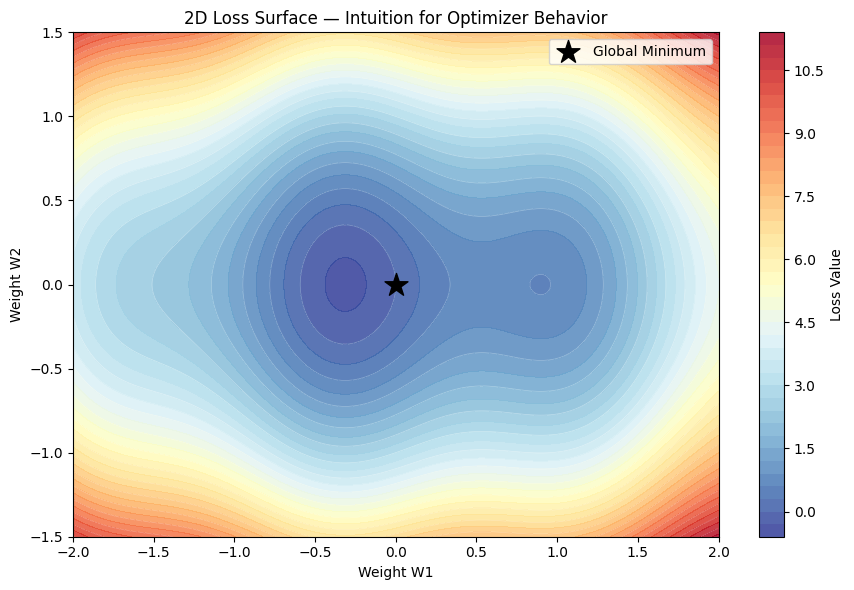

SGD oscillates in curved valleys. Momentum dampens oscillations. Adam adapts step size per dimension.


In [8]:
# Visualize a 2D loss surface to build intuition (simplified analogy)
x = np.linspace(-2, 2, 200)
y = np.linspace(-1.5, 1.5, 200)
X_g, Y_g = np.meshgrid(x, y)
Z_g = X_g**2 + 3*Y_g**2 + 0.5*np.sin(4*X_g)

plt.figure(figsize=(9, 6))
plt.contourf(X_g, Y_g, Z_g, levels=40, cmap='RdYlBu_r', alpha=0.85)
plt.colorbar(label='Loss Value')
plt.contour(X_g, Y_g, Z_g, levels=20, colors='white', linewidths=0.5, alpha=0.4)
plt.scatter([0], [0], s=300, color='black', zorder=5, marker='*', label='Global Minimum')
plt.title('2D Loss Surface — Intuition for Optimizer Behavior')
plt.xlabel('Weight W1'); plt.ylabel('Weight W2')
plt.legend()
plt.tight_layout()
plt.show()
print('SGD oscillates in curved valleys. Momentum dampens oscillations. Adam adapts step size per dimension.')

---
## Summary Table

| Optimizer | Key Idea | Strength | Weakness |
|-----------|---------|----------|----------|
| SGD | Fixed LR gradient steps | Simple, generalizes well | Slow, oscillates |
| SGD+Momentum | Accumulated velocity | Faster, smoother | Needs LR/momentum tuning |
| Nesterov | Look-ahead gradient | More accurate momentum | Slightly complex |
| Adam | Adaptive per-param LR | Fast, robust, minimal tuning | May overfit on small data |

